In [30]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib as mpl

In [2]:
class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [3]:
import src.compute.stats as stats_module
# from data import b_naive, b_memory

import importlib
import src.plot.tracks.reconstruct as reconstruct_module
import src.batch.tree as batch_tree_module
import src.io.load as load_module


In [13]:
importlib.reload(load_module)

load_data = load_module.load_data

data = load_data(r"C:\Users\modri\Desktop\Lab\Peregrin project\Data\mem_cxcl12\#memory-cxcl12#BC39#Stablized_spots.csv", retain=['POSITION_Z'], split_filename=True, split_filename_delimiter='#', split_filename_position=2)

In [7]:
importlib.reload(batch_tree_module)

make_tree = batch_tree_module.make_tree

tree = make_tree("C:\\Users\\modri\\Desktop\\Lab\\Peregrin project\\Tree test")
# tree = make_tree("C:\\Users\\modri\\Desktop\\Lab\\Peregrin project")

# tree.show()

tree_dict = tree.get()
tree_list = tree.get(type='list')


# tree.get()


In [27]:
data

,track_id,time_point,x_coordinate,y_coordinate,POSITION_Z,set
0,196.0,0.0,446.049935,514.718016,0.0,BC39
1,46.0,0.0,105.142437,265.404884,0.0,BC39
2,193.0,0.0,57.339646,514.234949,0.0,BC39
3,199.0,0.0,533.838219,533.021939,0.0,BC39
4,198.0,0.0,962.196674,538.272284,0.0,BC39
...,...,...,...,...,...,...
24317,723.0,3540.0,11.838741,321.551650,0.0,BC39
24318,727.0,3540.0,41.932501,675.383134,0.0,BC39
24319,726.0,3540.0,17.251840,588.025299,0.0,BC39
24320,725.0,3540.0,19.554030,489.110600,0.0,BC39


In [166]:
import numpy as np
import pandas as pd


def craft_dummy_dataframe(
    n_tracks: int = 6,
    n_time_points: int = 100,
    seed: int | None = 20,
) -> pd.DataFrame:
    """
    Generate a synthetic dataset simulating cell trajectories,
    organised into 2 sets, each with 2 subsets.

    Cells perform a persistent random walk (correlated random walk) with
    per-cell speed and directional persistence, plus small positional noise,
    which mimics realistic migrating-cell behaviour.

    Returns a DataFrame with columns:
        'set', 'subset', 'track_id', 'time_point',
        'x_coordinate', 'y_coordinate'
    """
    rng = np.random.default_rng(seed)
    records = []

    sets = ['set_A', 'set_B']
    subsets = ['subset_1', 'subset_2']

    global_track_id = 0

    for set_name in sets:
        for subset_name in subsets:
            for _ in range(n_tracks):
                global_track_id += 1
                track_id = global_track_id

                # Each cell can appear/disappear at slightly different times
                start = rng.integers(0, n_time_points // 4)
                length = rng.integers(n_time_points // 2, n_time_points + 1)
                end = min(start + length, n_time_points)

                # Random starting position in a 2D field
                x, y = rng.uniform(0, 500), rng.uniform(0, 500)

                # Per-cell motility characteristics
                speed = rng.uniform(2.0, 8.0)          # mean step length
                persistence = rng.uniform(0.6, 0.98)   # directional memory (0-1)
                angle = rng.uniform(0, 2 * np.pi)      # initial heading

                for t in range(start, end):
                    records.append(
                        (set_name, subset_name, track_id, t, x, y)
                    )

                    # Update heading with persistence (correlated random walk)
                    angle += (1 - persistence) * rng.uniform(-np.pi, np.pi)

                    step = rng.normal(speed, speed * 0.2)
                    x += step * np.cos(angle) + rng.normal(0, 0.5)
                    y += step * np.sin(angle) + rng.normal(0, 0.5)

    df = pd.DataFrame(
        records,
        columns=[
            'set', 'subset', 'track_id',
            'time_point', 'x_coordinate', 'y_coordinate',
        ],
    )
    df = df.sort_values(
        ['set', 'subset', 'track_id', 'time_point']
    ).reset_index(drop=True)

    df['track_uid'] = df.groupby(['set', 'subset', 'track_id']).ngroup()

    return df


df = craft_dummy_dataframe()
df

,set,subset,track_id,time_point,x_coordinate,y_coordinate,track_uid
0,set_A,subset_1,1,22,230.573355,60.859846,0
1,set_A,subset_1,1,23,234.227119,60.628657,0
2,set_A,subset_1,1,24,239.168127,60.344644,0
3,set_A,subset_1,1,25,242.898700,57.809882,0
4,set_A,subset_1,1,26,245.228029,54.597547,0
...,...,...,...,...,...,...,...
1708,set_B,subset_2,24,95,165.663738,651.145494,23
1709,set_B,subset_2,24,96,160.947074,653.762386,23
1710,set_B,subset_2,24,97,151.214694,656.336399,23
1711,set_B,subset_2,24,98,146.936610,659.480518,23


In [205]:
importlib.reload(stats_module)

stats = stats_module.stats

def test_spots(categories: list[str] | None = None) -> pd.DataFrame:
    df = craft_dummy_dataframe()
    spots = stats.spots(df)

    columns =  ['track_id', 'time_point', 'x_coordinate', 'y_coordinate', 'frame', 'distance', 
                'cum_track_length', 'cum_track_displacement', 'cum_straightness_ratio', 'cum_speed_mean',
                'cum_mean_straight_line_speed', 'cum_forward_progression_linearity', 'direction', 
                'directional_change', 'cum_sum_directional_change', 'cum_mean_directional_change', 
                'cum_mean_directional_change_rate', 'cum_direction_mean', 'cum_direction_var']

    if categories is not None:
        if not isinstance(categories, list) or not all(isinstance(cat, str) for cat in categories):
            raise ValueError("categories must be a list of strings")
        columns += categories

    for col in columns:
        assert col in spots.columns, f"Column {col} is missing in spots DataFrame"

    return spots

spots = test_spots(['set', 'subset'])
spots

,set,subset,track_id,time_point,x_coordinate,y_coordinate,frame,distance,cum_track_length,cum_track_displacement,...,cum_speed_mean,cum_mean_straight_line_speed,cum_forward_progression_linearity,direction,directional_change,cum_sum_directional_change,cum_mean_directional_change,cum_mean_directional_change_rate,cum_direction_mean,cum_direction_var
track_uid,,,,,,,,,,,,,,,,,,,,,
0,set_A,subset_1,1,22,230.573355,60.859846,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,set_A,subset_1,1,23,234.227119,60.628657,1,3.661071,3.661071,3.661071,...,3.661071,1.830535,0.500000,-0.063190,NaN,NaN,NaN,NaN,-0.063190,0.000000
0,set_A,subset_1,1,24,239.168127,60.344644,2,4.949165,8.610235,8.610200,...,4.305118,2.870067,0.666664,-0.057418,0.330747,0.330747,0.330747,0.110249,-0.060304,0.000004
0,set_A,subset_1,1,25,242.898700,57.809882,3,4.510232,13.120467,12.697103,...,4.373489,3.174276,0.725799,-0.596805,30.904621,31.235368,15.617684,3.904421,-0.237185,0.031728
0,set_A,subset_1,1,26,245.228029,54.597547,4,3.967980,17.088447,15.936620,...,4.272112,3.187324,0.746077,-0.943409,19.858979,51.094346,17.031449,3.406290,-0.412410,0.069341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,set_B,subset_2,24,95,165.663738,651.145494,73,6.204479,466.606803,433.355841,...,6.391874,5.856160,0.916188,2.571644,18.846007,675.379179,9.380266,0.126760,1.639609,0.072347
23,set_B,subset_2,24,96,160.947074,653.762386,74,5.393981,472.000784,436.290539,...,6.378389,5.817207,0.912018,2.635058,3.633354,679.012533,9.301542,0.124021,1.651899,0.077460
23,set_B,subset_2,24,97,151.214694,656.336399,75,10.067014,482.067798,439.679452,...,6.427571,5.785256,0.900069,2.883033,14.207968,693.220500,9.367845,0.123261,1.665642,0.085232



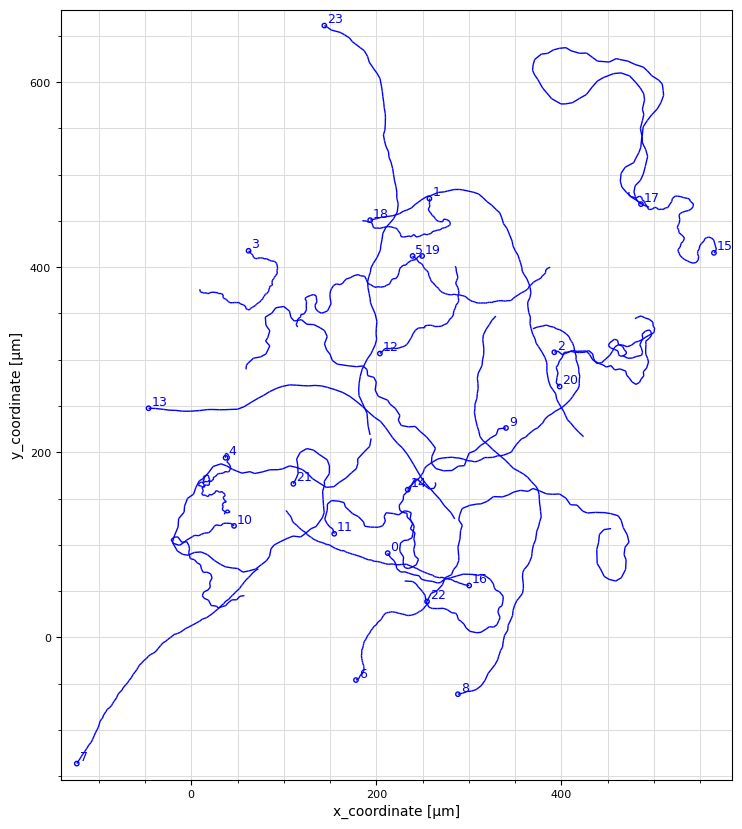

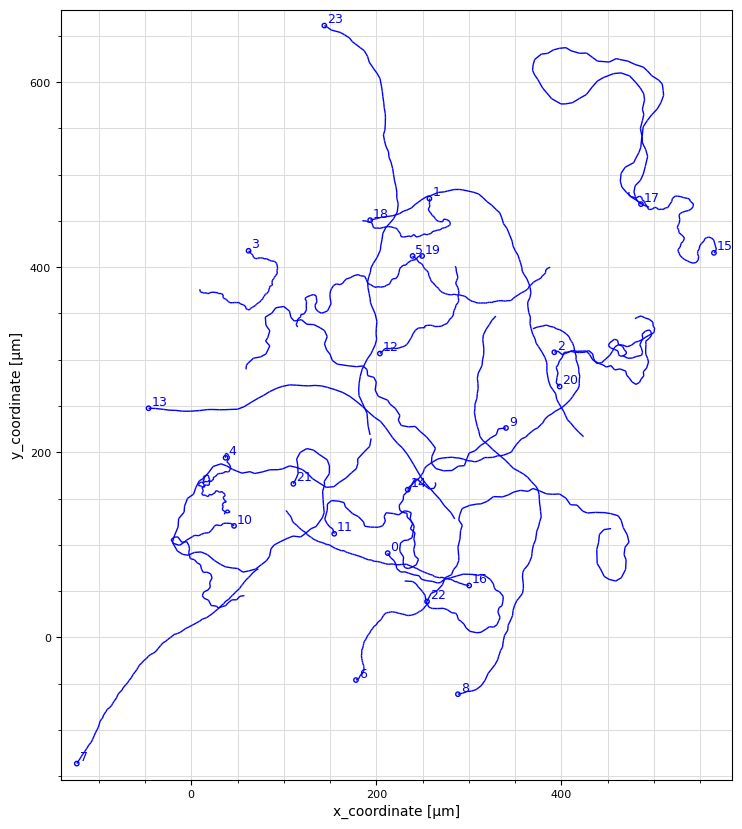

In [193]:
importlib.reload(reconstruct_module)

reconstruct_tracks = reconstruct_module.reconstruct

reconstruct_tracks(spots, display_uid=True, color='blue')

In [199]:
importlib.reload(stats_module)

stats = stats_module.stats

def test_tracks(categories: list[str] | None = None) -> pd.DataFrame:
    df = craft_dummy_dataframe()
    spots = stats.spots(df)
    tracks = stats.tracks(spots, categories=categories)

    columns = ['track_id', 'track_length', 'speed_min', 'speed_max', 'speed_mean', 'speed_sd', 
               'speed_median', 'x_location', 'y_location', 'max_distance_reached', 'track_start_frame', 
               'track_start_time', 'track_end_frame', 'track_end_time', 'mean_straight_line_speed', 
               'forward_progression_linearity', 'direction_mean', 'direction_var', 'mean_directional_change', 
               'mean_directional_change_rate', 'track_displacement', 'straightness_ratio', 'track_points']

    if categories is not None:
        if not isinstance(categories, list) or not all(isinstance(cat, str) for cat in categories):
            raise ValueError("categories must be a list of strings")
        columns += categories

    for col in columns:
        assert col in tracks.columns, f"Column {col} is missing in tracks DataFrame"

    return tracks

tracks = test_tracks(['set', 'subset'])

In [204]:
importlib.reload(stats_module)

stats = stats_module.stats

frames = stats.frames(spots)
frames.columns


def test_frames(categories: list[str] | None = None) -> pd.DataFrame:
    df = craft_dummy_dataframe()
    spots = stats.spots(df)
    frames = stats.frames(spots, grouping_level=['highest', 'lowest'], categories=categories)

    columns = ['time_point', 'frame', 'cum_track_length_min', 'cum_track_length_max', 
               'cum_track_length_mean', 'cum_track_length_median', 'cum_track_length_sd',
               'cum_track_displacement_min', 'cum_track_displacement_max', 'cum_track_displacement_mean', 
               'cum_track_displacement_median', 'cum_track_displacement_sd', 'cum_straightness_ratio_min',
               'cum_straightness_ratio_max', 'cum_straightness_ratio_mean', 'cum_straightness_ratio_median', 
               'cum_straightness_ratio_sd', 'cum_speed_mean_min', 'cum_speed_mean_max', 'cum_speed_mean_mean',
               'cum_speed_mean_median', 'cum_speed_mean_sd', 'instantaneous_speed_min', 'instantaneous_speed_max', 
               'instantaneous_speed_mean', 'instantaneous_speed_median', 'instantaneous_speed_sd',
               'cum_mean_straight_line_speed_min', 'cum_mean_straight_line_speed_max',
               'cum_mean_straight_line_speed_mean', 'cum_mean_straight_line_speed_median',
               'cum_mean_straight_line_speed_sd', 'cum_forward_progression_linearity_min',
               'cum_forward_progression_linearity_max', 'cum_forward_progression_linearity_mean',
               'cum_forward_progression_linearity_median', 'cum_forward_progression_linearity_sd',
               'cum_sum_directional_change_min', 'cum_sum_directional_change_max', 
               'cum_sum_directional_change_mean', 'cum_sum_directional_change_median', 
               'cum_sum_directional_change_sd', 'cum_mean_directional_change_min', 
               'cum_mean_directional_change_max', 'cum_mean_directional_change_mean',
               'cum_mean_directional_change_median', 'cum_mean_directional_change_sd',
               'instantaneous_direction_mean', 'instantaneous_direction_var',
               'cum_direction_mean', 'cum_direction_var', 'grouping_level']

    if categories is not None:
        if not isinstance(categories, list) or not all(isinstance(cat, str) for cat in categories):
            raise ValueError("categories must be a list of strings")
        columns += categories

    for col in columns:
        assert col in frames.columns, f"Column {col} is missing in frames DataFrame"

    return frames

frames = test_frames(['set'])
frames

,set,time_point,frame,cum_track_length_min,cum_track_length_max,cum_track_length_mean,cum_track_length_median,cum_track_length_sd,cum_track_displacement_min,cum_track_displacement_max,...,cum_mean_directional_change_max,cum_mean_directional_change_mean,cum_mean_directional_change_median,cum_mean_directional_change_sd,instantaneous_direction_mean,instantaneous_direction_var,cum_direction_mean,cum_direction_var,grouping_level,subset
0,set_A,22,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,set,NaN
1,set_A,23,1,2.848306,3.661071,3.254688,3.254688,0.574711,2.848306,3.661071,...,NaN,NaN,NaN,NaN,-1.420036,0.787678,-1.420036,7.876783e-01,set,NaN
2,set_A,24,2,5.670372,8.610235,7.140304,7.140304,2.078797,5.590207,8.610200,...,19.291822,9.811284,9.811284,13.407505,-1.248797,0.629621,-1.334417,7.076498e-01,set,NaN
3,set_A,25,3,8.714473,13.120467,10.917470,10.917470,3.115509,7.761633,12.697103,...,32.089525,23.853604,23.853604,11.647351,-1.126776,0.137178,-1.268392,4.862167e-01,set,NaN
4,set_A,26,4,11.187482,17.088447,14.137965,14.137965,4.172612,10.231806,15.936620,...,32.322404,24.676926,24.676926,10.812338,-1.586209,0.199579,-1.346413,4.053798e-01,set,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2927,set_B,95,73,466.606803,466.606803,466.606803,466.606803,NaN,433.355841,433.355841,...,9.380266,9.380266,9.380266,NaN,2.571644,0.000000,1.639609,1.110223e-16,subset,subset_1
2928,set_B,96,74,472.000784,472.000784,472.000784,472.000784,NaN,436.290539,436.290539,...,9.301542,9.301542,9.301542,NaN,2.635058,0.000000,1.651899,0.000000e+00,subset,subset_1
2929,set_B,97,75,482.067798,482.067798,482.067798,482.067798,NaN,439.679452,439.679452,...,9.367845,9.367845,9.367845,NaN,2.883033,0.000000,1.665642,0.000000e+00,subset,subset_1
2930,set_B,98,76,487.376987,487.376987,487.376987,487.376987,NaN,443.235188,443.235188,...,9.529596,9.529596,9.529596,NaN,2.507802,0.000000,1.676412,0.000000e+00,subset,subset_1


In [14]:
importlib.reload(stats_module)

stats = stats_module.stats

tlags = stats.time_intervals(spots, grouping_level=['highest', 'lowest'])

display(tlags)

,set,frame_lag,time_lag,MSD,MSD_sd,tracks_contributing,position_pairs_contributing,directional_change_mean,directional_change_var,grouping_level
0,BC39,1,60.0,281733.010128,253623.674615,1,23937,100.158608,0.994109,set
1,BC39,2,120.0,279770.761275,251268.544166,1,23539,10.223620,0.994766,set
2,BC39,3,180.0,281662.991958,252703.855991,1,23143,8.103293,0.998343,set
3,BC39,4,240.0,280009.028249,251435.683727,1,22749,141.027226,0.999562,set
4,BC39,5,300.0,278145.754522,249755.080088,1,22356,12.595815,0.998709,set
...,...,...,...,...,...,...,...,...,...,...
113,BC39,55,3300.0,353268.605033,312092.224166,1,2110,158.940384,0.989347,set
114,BC39,56,3360.0,349120.221164,299428.653387,1,1690,177.133354,0.983847,set
115,BC39,57,3420.0,350605.070327,323313.777707,1,1268,33.931196,0.987125,set
116,BC39,58,3480.0,385215.698883,367683.006208,1,846,96.917613,0.965679,set


In [15]:
importlib.reload(load_module)

load_data = load_module.load_data

data = load_data(tree_list, retain=['POSITION_Z'])
data

spots = stats.spots(data)
spots

,track_id,time_point,x_coordinate,y_coordinate,POSITION_Z,set,subset,group,frame,distance,...,cum_speed_mean,cum_mean_straight_line_speed,cum_forward_progression_linearity,direction,directional_change,cum_sum_directional_change,cum_mean_directional_change,cum_mean_directional_change_rate,cum_direction_mean,cum_direction_var
track_uid,,,,,,,,,,,,,,,,,,,,,
0,163.0,0.0,359.146286,213.254098,0.0,1,1,#memory-ctr#BC39#Stablized_spots.csv,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,62.0,0.0,249.731203,868.255973,0.0,1,1,#memory-ctr#BC39#Stablized_spots.csv,0,664.077643,...,NaN,5.533980,NaN,1.736314,NaN,NaN,NaN,NaN,1.736314,0.000000
0,61.0,0.0,780.128167,742.540054,0.0,1,1,#memory-ctr#BC39#Stablized_spots.csv,0,545.092132,...,NaN,3.757172,NaN,-0.232728,112.817745,1.128177e+02,112.817745,0.626765,0.751793,0.446737
0,335.0,0.0,818.683978,598.562539,0.0,1,1,#memory-ctr#BC39#Stablized_spots.csv,0,149.050580,...,NaN,2.498741,NaN,-1.309145,61.674175,1.744919e+02,87.245960,0.363525,-0.194575,0.637508
0,346.0,0.0,766.602304,630.277660,0.0,1,1,#memory-ctr#BC39#Stablized_spots.csv,0,60.978272,...,NaN,1.943448,NaN,2.594618,136.330830,3.108228e+02,103.607584,0.345359,0.968869,0.906023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,207.0,3540.0,887.549547,653.577613,0.0,3,2,#naive-mu#BC43#Stablized_spots.csv,59,575.004396,...,1539.720654,0.000033,2.118252e-08,-0.124230,55.744093,1.208201e+06,121.135093,0.000202,3.022650,0.995946
31,206.0,3540.0,1122.513345,99.981158,0.0,3,2,#naive-mu#BC43#Stablized_spots.csv,59,601.395894,...,1539.890540,0.000973,6.316901e-07,-1.169407,59.884274,1.208261e+06,121.128953,0.000202,3.044369,0.995995
31,0.0,3540.0,898.248052,636.855243,0.0,3,2,#naive-mu#BC43#Stablized_spots.csv,59,581.832196,...,1540.054899,0.000001,8.797343e-10,1.966488,179.673575,1.208441e+06,121.134821,0.000202,3.022580,0.995947


In [16]:
spots = stats.spots(b_naive.ctr)
tracks = stats.tracks(spots)

NameError: name 'b_naive' is not defined

In [ ]:
spots

In [ ]:

# # reconstruct(spots, color="black")

# importlib.reload(reconstruct_module)

# reconstruct = reconstruct_module.reconstruct

# print('run 1')
# reconstruct(spots, common_start=True, color='black', show_heads=True, ignore_categories=True)

# print('run 2')
# reconstruct(spots, common_start=True, color_by='distance', show_heads=True, ignore_categories=True)

# print('run 3')
# reconstruct(spots, common_start=False, color_by='distance', show_heads=True, ignore_categories=True)

# print('run 4')
# reconstruct(spots, common_start=False, color='random', show_heads=True, ignore_categories=True)

In [ ]:
%matplotlib widget

importlib.reload(reconstruct_module)
reconstruct = reconstruct_module.reconstruct
result = reconstruct(spots, color='random', align_at_start=True)

In [ ]:
%matplotlib widget

mpl.rcParams['animation.embed_limit'] = 50


anim = result.animate(speed=2.0, interval=20, controls=True, mode="jshtml")
anim

# result.figure.show()